In [1]:
# First we import basic libraries that I need to data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Then we import the data set
df = pd.read_csv('personality_dataset.csv')

# In here we explore the data set using following lines
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

#We Drop duplicates because It affects to accuracy of the model
df.drop_duplicates(inplace=True)

# Here we replace missing values in numerical columns(using median for numerical to handle potential outliers)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Replace missing categorical values with the mode
categorical_cols = ['Stage_fear', 'Drained_after_socializing']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB
None
       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2837.000000              2838.000000    2834.000000   
mean           4.505816                 3.963354       3.000000   
std            3.479192                 2.903827       2.247327   
min    

C:\Users\MIKAZ-PC\AppData\Local\Temp\ipykernel_36736\2575420890.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\MIKAZ-PC\AppData\Local\Temp\ipykernel_36736\2575420890.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

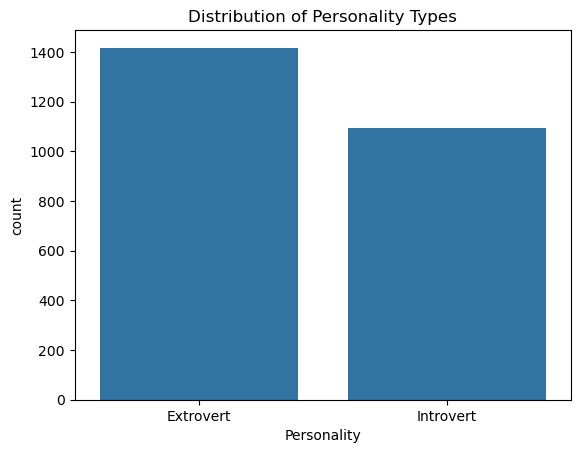

In [2]:
# Visualize class distribution (Imbalance check)
sns.countplot(data=df, x='Personality')
plt.title('Distribution of Personality Types')
plt.show()

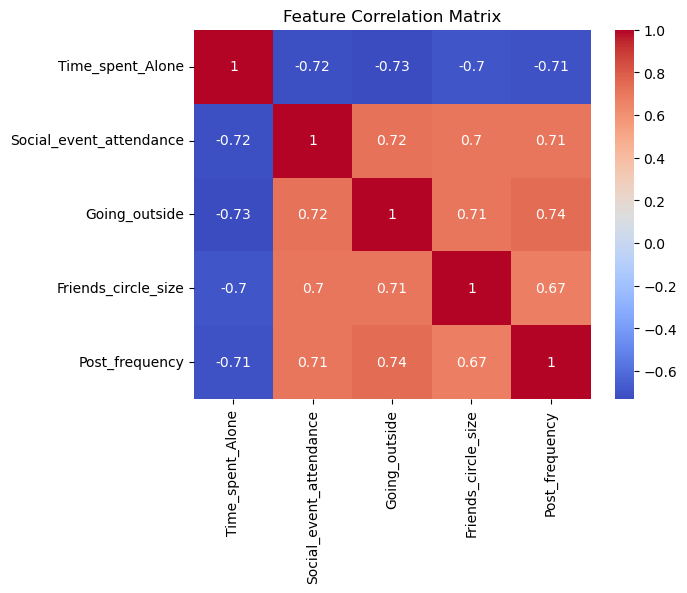

In [3]:
# Visualize correlations for numerical features
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Separate features (X) and target (y)
X = df.drop('Personality', axis=1)
y = df['Personality']

# In here we Encode the Target Variable as Extrovert -> 0, Introvert -> 1 (or vice versa)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) 


# We use ColumnTransformer to apply different preprocessing to numerical vs categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols) 
    ])

X_processed = preprocessor.fit_transform(X)


print(f"Final feature matrix shape: {X_processed.shape}")

Final feature matrix shape: (2512, 7)


In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
# Load the RandomForestAlgorithm
rf_model = RandomForestClassifier(random_state=42)

# Here is the part that train the model and perform cross validation test
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



Cross-Validation Accuracy: 0.9109 (+/- 0.0179)


In [6]:
from sklearn.model_selection import GridSearchCV
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       284
   Introvert       0.88      0.93      0.90       219

    accuracy                           0.91       503
   macro avg       0.91      0.92      0.91       503
weighted avg       0.92      0.91      0.91       503



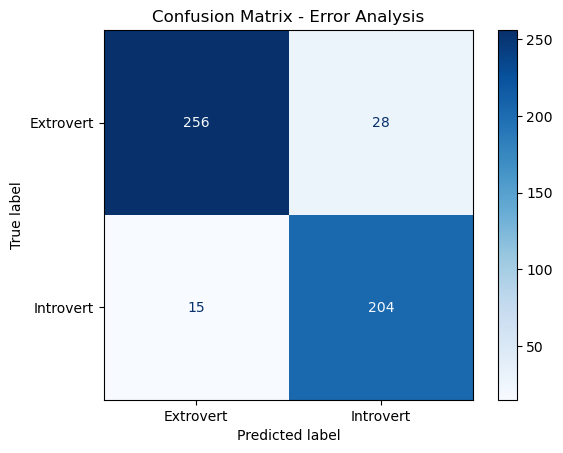

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split 

# Predict the test data set using trained model
y_pred = best_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# plot the confusion matrix and get Precision, Recall, F1-Score to error analysis
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Error Analysis')
plt.show()


In [8]:
import joblib

#Finally we save the preprocessor and personality predicting model
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(best_model,'personality_model.pkl')




['personality_model.pkl']